# II) Binary liver segmentation: U_Net Baseline
## Mansour Arefi
### CM2026 Advanced Machine Learning for Data-driven-Health

This notebook contains of training a simple baseline model with the U-net architecture provided in this assignments description. The training is done with 10 patients (there we use the whole volym av each patient), static LR and 10 epochs without early stop. 

## 1. Imports/device/Path

In [ ]:
%pip install -q albumentations opencv-python-headless

In [2]:
import os
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from tqdm.auto import tqdm

import random


EXP_NAME = "baseline_10p"
TRAIN_PATIENTS = 10
LOSS_NAME = "weighted_ce"
LR = 1e-4
BATCH_SIZE = 8

NUM_EPOCHS = 10
WEIGHT_DECAY = 1e-4
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("EXP_NAME:", EXP_NAME)
print("TRAIN_PATIENTS:", TRAIN_PATIENTS)
print("LOSS_NAME:", LOSS_NAME)
print("LR:", LR)
print("BATCH_SIZE:", BATCH_SIZE)
print("Seed fixed:", SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

In [5]:
PATIENT_INDEX_CSV = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/patient_index.csv"
SPLIT_JSON = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/split.json"
STATS_JSON = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta/stats.json"

META_DIR = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta"
BASE_DIR = "/kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes"
VOLUME_DIR = BASE_DIR + "/volumes"

print("META_DIR:", META_DIR)
print("BASE_DIR:", BASE_DIR)
print("VOLUME_DIR:", VOLUME_DIR)

META_DIR: /kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/meta
BASE_DIR: /kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes
VOLUME_DIR: /kaggle/input/datasets/mansourarefi/volyms-v1/abdomen_cache_volumes/volumes


## 2. Load dataset  

In [6]:
df_patients = pd.read_csv(PATIENT_INDEX_CSV)

with open(SPLIT_JSON, "r") as f:
    split = json.load(f)

with open(STATS_JSON, "r") as f:
    stats = json.load(f)

CLIP_RANGE = tuple(stats["clip_range"])

print("Number of cached patients:", len(df_patients))
print("Train patients:", len(split["train"]), split["train"])
print("Val patients:", len(split["val"]), split["val"])
print("Test patients:", len(split["test"]), split["test"])
print("CLIP_RANGE:", CLIP_RANGE)

df_patients

Number of cached patients: 100
Train patients: 60 ['BDMAP_00000037', 'BDMAP_00000024', 'BDMAP_00000040', 'BDMAP_00000041', 'BDMAP_00000019', 'BDMAP_00000067', 'BDMAP_00000062', 'BDMAP_00000061', 'BDMAP_00000008', 'BDMAP_00000035', 'BDMAP_00000100', 'BDMAP_00000047', 'BDMAP_00000003', 'BDMAP_00000052', 'BDMAP_00000017', 'BDMAP_00000039', 'BDMAP_00000059', 'BDMAP_00000069', 'BDMAP_00000023', 'BDMAP_00000063', 'BDMAP_00000025', 'BDMAP_00000006', 'BDMAP_00000007', 'BDMAP_00000068', 'BDMAP_00000083', 'BDMAP_00000020', 'BDMAP_00000080', 'BDMAP_00000044', 'BDMAP_00000091', 'BDMAP_00000021', 'BDMAP_00000001', 'BDMAP_00000096', 'BDMAP_00000058', 'BDMAP_00000094', 'BDMAP_00000054', 'BDMAP_00000090', 'BDMAP_00000026', 'BDMAP_00000072', 'BDMAP_00000085', 'BDMAP_00000078', 'BDMAP_00000065', 'BDMAP_00000030', 'BDMAP_00000028', 'BDMAP_00000089', 'BDMAP_00000098', 'BDMAP_00000005', 'BDMAP_00000055', 'BDMAP_00000076', 'BDMAP_00000012', 'BDMAP_00000070', 'BDMAP_00000087', 'BDMAP_00000014', 'BDMAP_000000

,case_id,case_folder,npz_name,height,width,depth,positive_slices,negative_slices,ct_min,ct_max
0,BDMAP_00000001,cm2026/BDMAP_00000001,BDMAP_00000001.npz,511,404,339,55,284,-1000.0,1000.0
1,BDMAP_00000002,cm2026/BDMAP_00000002,BDMAP_00000002.npz,403,313,201,155,46,-999.0,999.0
2,BDMAP_00000003,cm2026/BDMAP_00000003,BDMAP_00000003.npz,301,212,215,138,77,-999.0,999.0
3,BDMAP_00000004,cm2026/BDMAP_00000004,BDMAP_00000004.npz,512,368,91,30,61,-999.0,999.0
4,BDMAP_00000005,cm2026/BDMAP_00000005,BDMAP_00000005.npz,512,395,509,187,322,-1000.0,1000.0
...,...,...,...,...,...,...,...,...,...,...
95,BDMAP_00000096,cm2026/BDMAP_00000096,BDMAP_00000096.npz,512,362,81,31,50,-999.0,999.0
96,BDMAP_00000097,cm2026/BDMAP_00000097,BDMAP_00000097.npz,512,368,532,230,302,-1000.0,1000.0
97,BDMAP_00000098,cm2026/BDMAP_00000098,BDMAP_00000098.npz,512,356,978,229,749,-1000.0,1000.0
98,BDMAP_00000099,cm2026/BDMAP_00000099,BDMAP_00000099.npz,512,482,532,199,333,-1000.0,1000.0


## Helperfunction to decide wether to with all, positiv_only or balanced chosen slices 

In [9]:
SLICE_POLICY = "all"   # "all", "positive_only", "balanced"
NEGATIVE_KEEP_RATIO = 0.3  # uses only if  SLICE_POLICY = "balanced"


def build_slice_index(df_patients, volume_dir, slice_policy="all", negative_keep_ratio=1.0):
    rows = []

    for _, row in tqdm(df_patients.iterrows(), total=len(df_patients), desc="Building slice index"):
        case_id = row["case_id"]
        npz_name = row["npz_name"]

        data = np.load(volume_dir + "/" + npz_name)
        liver_vol = data["liver_vol"]   # [H, W, D] 

        depth = liver_vol.shape[2]
        positive_per_slice = (liver_vol.sum(axis=(0, 1)) > 0)

        positive_indices = np.where(positive_per_slice)[0]
        negative_indices = np.where(~positive_per_slice)[0]

        if slice_policy == "all":
            selected_indices = np.arange(depth)

        elif slice_policy == "positive_only":
            selected_indices = positive_indices

        elif slice_policy == "balanced":
            rng = np.random.default_rng(SEED)
            n_neg = int(len(negative_indices) * negative_keep_ratio)
            if n_neg > 0 and len(negative_indices) > n_neg:
                neg_selected = rng.choice(negative_indices, size=n_neg, replace=False)
                neg_selected = np.sort(neg_selected)
            else:
                neg_selected = negative_indices

            selected_indices = np.sort(np.concatenate([positive_indices, neg_selected]))

        else:
            raise ValueError(f"Unknown slice_policy: {slice_policy}")

        for z in selected_indices:
            rows.append({
                "case_id": case_id,
                "npz_name": npz_name,
                "slice_idx": int(z),
                "has_liver": int(positive_per_slice[z]),
            })

    return pd.DataFrame(rows)

Here we follow the split made in i_data_prepreation and here we take 10 patients for training step and whole 20val/20test set.

In [10]:
train_subset_ids = split["train"][:TRAIN_PATIENTS]
val_case_ids = split["val"]
test_case_ids = split["test"]

df_train_patients = df_patients[df_patients["case_id"].isin(train_subset_ids)].reset_index(drop=True)
df_val_patients = df_patients[df_patients["case_id"].isin(val_case_ids)].reset_index(drop=True)
df_test_patients = df_patients[df_patients["case_id"].isin(test_case_ids)].reset_index(drop=True)

print("Train patients used:", len(df_train_patients))
print("Val patients used:", len(df_val_patients))
print("Test patients used:", len(df_test_patients))
print("Train IDs used:", train_subset_ids)

df_train_slices = build_slice_index(
    df_train_patients,
    VOLUME_DIR,
    slice_policy=SLICE_POLICY,
    negative_keep_ratio=NEGATIVE_KEEP_RATIO
)

df_val_slices = build_slice_index(
    df_val_patients,
    VOLUME_DIR,
    slice_policy="all",
    negative_keep_ratio=1.0
)

df_test_slices = build_slice_index(
    df_test_patients,
    VOLUME_DIR,
    slice_policy="all",
    negative_keep_ratio=1.0
)

print("Train slices:", len(df_train_slices))
print("Val slices:", len(df_val_slices))
print("Test slices:", len(df_test_slices))

Train patients used: 10
Val patients used: 20
Test patients used: 20
Train IDs used: ['BDMAP_00000037', 'BDMAP_00000024', 'BDMAP_00000040', 'BDMAP_00000041', 'BDMAP_00000019', 'BDMAP_00000067', 'BDMAP_00000062', 'BDMAP_00000061', 'BDMAP_00000008', 'BDMAP_00000035']


Building slice index:   0%|          | 0/10 [00:00<?, ?it/s]

Building slice index:   0%|          | 0/20 [00:00<?, ?it/s]

Building slice index:   0%|          | 0/20 [00:00<?, ?it/s]

Train slices: 2735
Val slices: 7350
Test slices: 5583


In [11]:
print("Train slice class balance:")
print(df_train_slices["has_liver"].value_counts())

print(df_train_slices.shape)

print("\nVal slice class balance:")
print(df_val_slices["has_liver"].value_counts())

print("\nTest slice class balance:")
print(df_test_slices["has_liver"].value_counts())

Train slice class balance:
has_liver
0    1693
1    1042
Name: count, dtype: int64
(2735, 4)

Val slice class balance:
has_liver
0    4966
1    2384
Name: count, dtype: int64

Test slice class balance:
has_liver
0    3299
1    2284
Name: count, dtype: int64


## Helperfunction to estimate mean and std from chosen patients

In [12]:
def estimate_mean_std_from_chosen_patients(df_slices, volume_dir, clip_range=(-100, 400)):
    values_sum = 0.0
    values_sq_sum = 0.0
    n_pixels = 0

    # grouped by npz_name so we load the whole volume once
    grouped = df_slices.groupby("npz_name")
    
    for npz_name, group in tqdm(grouped, desc="Estimating mean/std"):
        # load the volume
        data = np.load(f"{volume_dir}/{npz_name}")
        ct_vol = data["ct_vol"].astype(np.float32)
        
        slice_indices = group["slice_idx"].values
        
        selected_slices = ct_vol[:, :, slice_indices]
        
        selected_slices = np.clip(selected_slices, *clip_range)

        values_sum += selected_slices.sum()
        values_sq_sum += (selected_slices ** 2).sum()
        n_pixels += selected_slices.size

    mean = values_sum / n_pixels
    std = np.sqrt(values_sq_sum / n_pixels - mean ** 2)
    return float(mean), float(std)


dataset_mean, dataset_std = estimate_mean_std_from_chosen_patients(
    df_train_slices,
    VOLUME_DIR,
    clip_range=CLIP_RANGE
)

print("dataset_mean:", dataset_mean)
print("dataset_std:", dataset_std)

Estimating mean/std:   0%|          | 0/10 [00:00<?, ?it/s]

dataset_mean: -38.629432678222656
dataset_std: 99.58291625976562


## 3. Augmentation
For the baseline we chose only a easy horizontalFlip (try to keep it simple)

In [13]:
height, width = 256, 256

train_transform = A.Compose([
    A.Resize(height, width),
    A.HorizontalFlip(p=0.5),
])

val_transform = A.Compose([
    A.Resize(height, width),
])

## 4. Dataset created from input

In [14]:
class SegmentationDatasetBaseline(Dataset):
    def __init__(self, df_slices, volume_dir, transform=None, clip_range=(-100, 400), mean=None, std=None):
        self.df = df_slices.reset_index(drop=True)
        self.volume_dir = Path(volume_dir)
        self.transform = transform
        self.clip_range = clip_range
        self.mean = mean
        self.std = std
        self.volume_cache = {}

    def __len__(self):
        return len(self.df)

    def _load(self, npz_name):
        if npz_name not in self.volume_cache:
            data = np.load(self.volume_dir / npz_name)
            ct_vol = data["ct_vol"].astype(np.float32)
            liver_vol = data["liver_vol"].astype(np.uint8)
            self.volume_cache[npz_name] = (ct_vol, liver_vol)
        return self.volume_cache[npz_name]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        npz_name = row["npz_name"]
        z = int(row["slice_idx"])

        ct_vol, liver_vol = self._load(npz_name)

        image = ct_vol[:, :, z].copy()
        mask = liver_vol[:, :, z].copy().astype(np.int64)

        image = np.clip(image, *self.clip_range)

        if self.mean is not None and self.std is not None:
            image = (image - self.mean) / (self.std + 1e-8)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [15]:
train_dataset = SegmentationDatasetBaseline(
    df_train_slices,
    volume_dir=VOLUME_DIR,
    transform=train_transform,
    clip_range=CLIP_RANGE,
    mean=dataset_mean,
    std=dataset_std
)

val_dataset = SegmentationDatasetBaseline(
    df_val_slices,
    volume_dir=VOLUME_DIR,
    transform=val_transform,
    clip_range=CLIP_RANGE,
    mean=dataset_mean,
    std=dataset_std
)

test_dataset = SegmentationDatasetBaseline(
    df_test_slices,
    volume_dir=VOLUME_DIR,
    transform=val_transform,
    clip_range=CLIP_RANGE,
    mean=dataset_mean,
    std=dataset_std
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

2735 7350 5583


## A sample (slice) from dataset that includes liver

In [16]:
positive_indices = df_train_slices[df_train_slices["has_liver"] == 1].index
idx = positive_indices[0] 

images, masks = train_dataset[idx]

print("image shape:", images.shape)
print("mask shape:", masks.shape)
print("image dtype:", images.dtype)
print("mask dtype:", masks.dtype)
print("mask unique values:", torch.unique(masks))

image shape: torch.Size([1, 256, 256])
mask shape: torch.Size([256, 256])
image dtype: torch.float32
mask dtype: torch.int64
mask unique values: tensor([0])


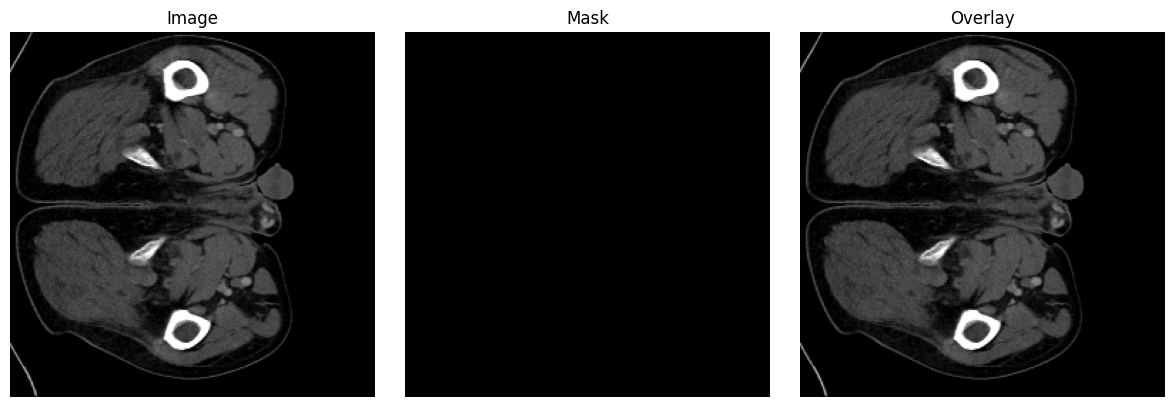

In [17]:
img = images[0].numpy()
msk = masks.numpy()
msk_overlay = np.ma.masked_where(msk == 0, msk)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(msk, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(msk_overlay, cmap="autumn", alpha=0.5)
plt.axis("off")

plt.tight_layout()
plt.show()

## Dataloaders

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## 5. Model - U-Net (Baseline)

In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, features=(64, 128, 256, 512)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        self.up_transpose = nn.ModuleList()
        self.ups = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.up_transpose.append(
                nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.up_transpose)):
            x = self.up_transpose[i](x)
            skip = skip_connections[i]

            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:], mode="bilinear", align_corners=False
                )

            x = torch.cat((skip, x), dim=1)
            x = self.ups[i](x)

        return self.final_conv(x)

## Weight Initialization

In [21]:
def init_weights_kaiming(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)

## Class weights for handle the imbalance in the data (liver vs. not liver)

In [ ]:
def estimate_class_weights_from_dataset(dataset):
    total_background = 0
    total_liver = 0

    for i in tqdm(range(len(dataset)), desc="Estimating class weights"):
        _, mask = dataset[i]
        total_liver += (mask == 1).sum().item()
        total_background += (mask == 0).sum().item()

    total = total_background + total_liver
    w_background = total / (2 * total_background)
    w_liver = total / (2 * total_liver)

    return torch.tensor([w_background , w_liver], dtype=torch.float32)

class_weights = estimate_class_weights_from_dataset(train_dataset)
print("Class weights:", class_weights)

## Now everything put together

In [22]:
model = UNet(in_channels=1, num_classes=2)
model.apply(init_weights_kaiming)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print("Model ready on:", device)
print("Loss:", LOSS_NAME)
print("LR:", LR)
print("Batch size:", BATCH_SIZE)



Model ready on: cuda
Loss: weighted_ce
LR: 0.0001
Batch size: 8


In [23]:
images_batch, masks_batch = next(iter(train_loader))
x = images_batch.to(device)
logits = model(x)

print("Input shape:", x.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([8, 1, 256, 256])
Logits shape: torch.Size([8, 2, 256, 256])


## Helper functions to do the training

In [24]:
def dice_score_from_logits(logits, targets, eps=1e-8):
    preds = torch.argmax(logits, dim=1).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits.detach(), masks)
        n_batches += 1

    return running_loss / max(n_batches, 1), running_dice / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, masks)
        n_batches += 1

    return running_loss / max(n_batches, 1), running_dice / max(n_batches, 1)

## Checkpoints

In [26]:
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints") / EXP_NAME
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LATEST_CKPT = CHECKPOINT_DIR / "checkpoint_latest.pt"
BEST_CKPT = CHECKPOINT_DIR / "best_model.pt"
HISTORY_JSON = CHECKPOINT_DIR / "history.json"

print(CHECKPOINT_DIR)

/kaggle/working/checkpoints/baseline_10p


## Training loop

In [27]:
num_epochs = NUM_EPOCHS
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_loss, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_dice = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_dice": best_val_dice,
        "history": history,
    }
    torch.save(checkpoint, LATEST_CKPT)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), BEST_CKPT)

    with open(HISTORY_JSON, "w") as f:
        json.dump(history, f, indent=2)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

Epoch 1/10 | train_loss=0.1614, train_dice=0.2656 | val_loss=0.0797, val_dice=0.2582
Epoch 2/10 | train_loss=0.0445, train_dice=0.4608 | val_loss=0.0629, val_dice=0.6288
Epoch 3/10 | train_loss=0.0406, train_dice=0.5142 | val_loss=0.0582, val_dice=0.7373
Epoch 4/10 | train_loss=0.0277, train_dice=0.6796 | val_loss=0.0481, val_dice=0.5432
Epoch 5/10 | train_loss=0.0212, train_dice=0.7404 | val_loss=0.1078, val_dice=0.8429
Epoch 6/10 | train_loss=0.0320, train_dice=0.7147 | val_loss=0.0733, val_dice=0.2452
Epoch 7/10 | train_loss=0.0318, train_dice=0.6326 | val_loss=0.0614, val_dice=0.6759
Epoch 8/10 | train_loss=0.0213, train_dice=0.7397 | val_loss=0.0582, val_dice=0.7802
Epoch 9/10 | train_loss=0.0132, train_dice=0.8491 | val_loss=0.0602, val_dice=0.7765
Epoch 10/10 | train_loss=0.0121, train_dice=0.8716 | val_loss=0.0882, val_dice=0.8440


##  Training curves

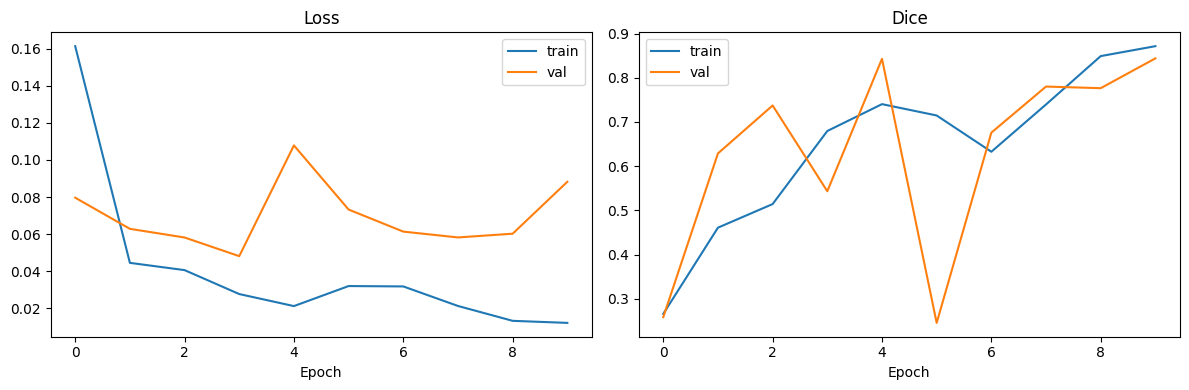

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_dice"], label="train")
plt.plot(history["val_dice"], label="val")
plt.title("Dice")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

## Test-set evaluation

In [29]:
best_model = UNet(in_channels=1, num_classes=2)
best_model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
best_model = best_model.to(device)
best_model.eval()

test_loss, test_dice = evaluate(best_model, test_loader, criterion, device)
print("Test loss:", test_loss)
print("Test dice:", test_dice)

Test loss: 0.2542212474255288
Test dice: 0.7760466303172691


In [30]:
@torch.no_grad()
def visualize_predictions(model, loader, device, num_examples=3):
    model.eval()

    shown = 0 # Håller koll på hur många bilder vi har ritat ut

    # Vi loopar igenom vår loader tills vi hittat tillräckligt många bilder
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        images = images.cpu().numpy()
        masks = masks.cpu().numpy()
        preds = preds.cpu().numpy()

        # Gå igenom varje bild i den aktuella batchen
        for i in range(len(images)):
            
            # KONTROLL: Har denna specifika mask någon lever i sig?
            if masks[i].sum() > 0: 
                
                img = images[i, 0]
                mask = masks[i]
                pred = preds[i]

                mask_overlay = np.ma.masked_where(mask == 0, mask)
                pred_overlay = np.ma.masked_where(pred == 0, pred)

                plt.figure(figsize=(15, 4))

                plt.subplot(1, 3, 1)
                plt.title("Image")
                plt.imshow(img, cmap="gray")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.title("Ground truth")
                plt.imshow(img, cmap="gray")
                plt.imshow(mask_overlay, cmap="autumn", alpha=0.5)
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.title("Prediction")
                plt.imshow(img, cmap="gray")
                plt.imshow(pred_overlay, cmap="autumn", alpha=0.5)
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1 # Vi har nu visat en bild
                
                # Avbryt hela funktionen när vi nått vårt mål (t.ex. 3 bilder)
                if shown >= num_examples:
                    return

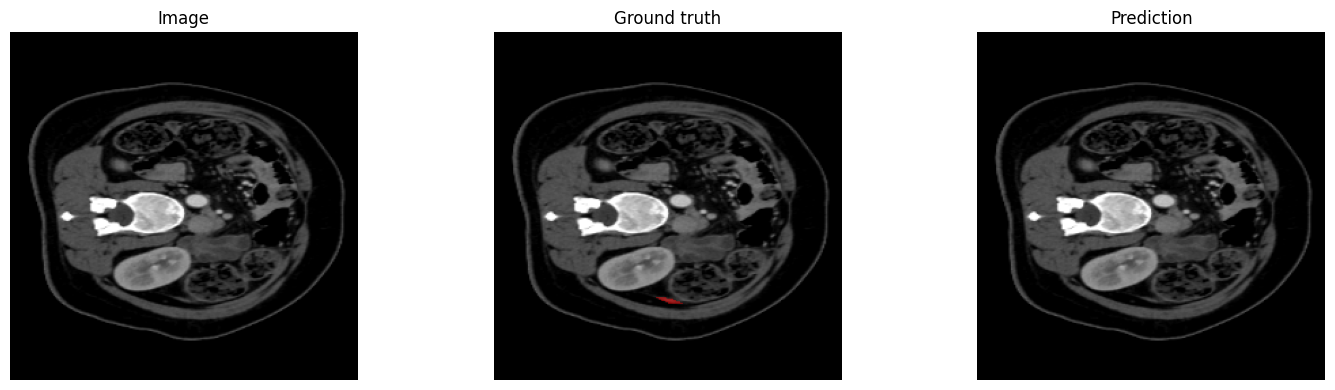

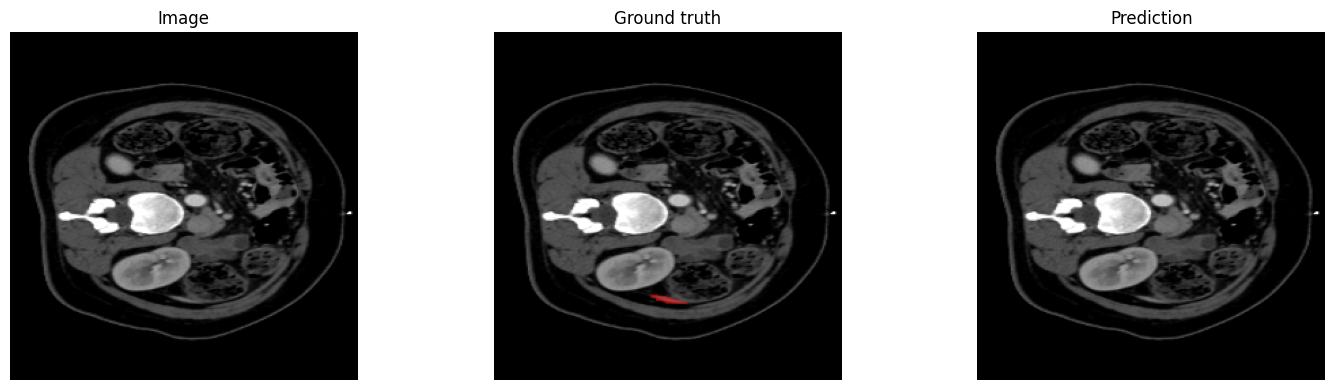

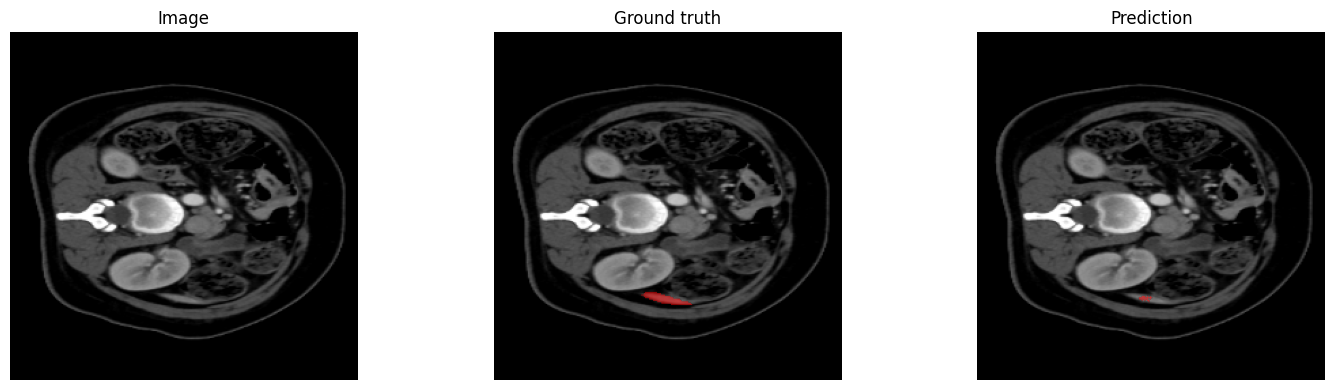

In [31]:
visualize_predictions(best_model, val_loader, device, num_examples=3)

In [32]:
@torch.no_grad()
def evaluate_II(model, loader, device, eps=1e-8):
    model.eval()

    dice_all = []
    dice_positive = []
    iou_all = []

    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        masks = masks.numpy()

        for pred, target in zip(preds, masks):
            tp = np.logical_and(pred == 1, target == 1).sum()
            fp = np.logical_and(pred == 1, target == 0).sum()
            fn = np.logical_and(pred == 0, target == 1).sum()

            dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
            iou = (tp + eps) / (tp + fp + fn + eps)

            dice_all.append(dice)
            iou_all.append(iou)

            if target.sum() > 0:
                dice_positive.append(dice)

    return {
        "test_dice_all_slices": float(np.mean(dice_all)),
        "test_dice_positive_slices": float(np.mean(dice_positive)) if len(dice_positive) > 0 else np.nan,
        "test_iou_all_slices": float(np.mean(iou_all)),
    }

extra_metrics = evaluate_II(best_model, test_loader, device)
print(extra_metrics)

{'test_dice_all_slices': 0.7761024232449922, 'test_dice_positive_slices': 0.8025305716107568, 'test_iou_all_slices': 0.7440705132538197}


In [33]:
experiment_config = {
    "exp_name": EXP_NAME,
    "model": "2D UNet",
    "slice_policy": SLICE_POLICY,
    "image_size": [256, 256],
    "clip_range": list(CLIP_RANGE),
    "optimizer": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "loss": LOSS_NAME,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "best_val_dice": max(history["val_dice"]),
    "test_loss": test_loss,
    "test_dice": test_dice,
    "test_dice_all_slices": extra_metrics["test_dice_all_slices"],
    "test_dice_positive_slices": extra_metrics["test_dice_positive_slices"],
    "test_iou_all_slices": extra_metrics["test_iou_all_slices"],
    "num_train_patients_requested": TRAIN_PATIENTS,
    "num_train_patients_actual": len(df_train_patients),
    "num_val_patients_actual": len(df_val_patients),
    "num_test_patients_actual": len(df_test_patients),
    "train_ids_used": train_subset_ids,
}

with open(CHECKPOINT_DIR / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

print(json.dumps(experiment_config, indent=2))

{
  "exp_name": "baseline_10p",
  "model": "2D UNet",
  "slice_policy": "all",
  "image_size": [
    256,
    256
  ],
  "clip_range": [
    -100,
    400
  ],
  "optimizer": "AdamW",
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "loss": "weighted_ce",
  "batch_size": 8,
  "num_epochs": 10,
  "best_val_dice": 0.8439931042967896,
  "test_loss": 0.2542212474255288,
  "test_dice": 0.7760466303172691,
  "test_dice_all_slices": 0.7761024232449922,
  "test_dice_positive_slices": 0.8025305716107568,
  "test_iou_all_slices": 0.7440705132538197,
  "num_train_patients_requested": 10,
  "num_train_patients_actual": 10,
  "num_val_patients_actual": 20,
  "num_test_patients_actual": 20,
  "train_ids_used": [
    "BDMAP_00000037",
    "BDMAP_00000024",
    "BDMAP_00000040",
    "BDMAP_00000041",
    "BDMAP_00000019",
    "BDMAP_00000067",
    "BDMAP_00000062",
    "BDMAP_00000061",
    "BDMAP_00000008",
    "BDMAP_00000035"
  ]
}
